In [ ]:
!pip install opendrift

In [1]:
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
from datetime import datetime, timedelta

In [2]:
o = OceanDrift(loglevel=20)

05:42:58 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)


In [3]:
from opendrift.readers.reader_netCDF_CF_generic import Reader

wind_reader = Reader(
    "./wind_data2.nc",
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)

o.add_reader(wind_reader)

05:43:13 INFO    opendrift.readers:63: Opening file with xr.open_dataset
05:43:14 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'valid_time', 'x': 'longitude', 'y': 'latitude'}


In [4]:
print(wind_reader)

Reader: ./wind_data2.nc
Projection: 
  +proj=latlong
Coverage: [degrees]
  xmin: 37.500000   xmax: 39.500000   step: 0.25   numx: 9
  ymin: 19.500000   ymax: 21.500000   step: 0.25   numy: 9
  Corners (lon, lat):
    ( 37.50,  21.50)  ( 39.50,  21.50)
    ( 37.50,  19.50)  ( 39.50,  19.50)
Vertical levels [m]: 
  Not specified
Available time range:
  start: 2025-01-01 07:00:00   end: 2025-01-04 14:00:00   step: 1:00:00
    80 times (60 missing)
Variables (1 ensemble members):
  x_wind
  y_wind
  wind_speed - derived from ['x_wind', 'y_wind']



In [5]:
from datetime import datetime, timedelta

o.seed_elements(
    lon=38.75,
    lat=20.50,
    radius=219.24,
    number=1000,
    time=datetime(2025, 1, 1, 7)
)

05:43:21 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
05:43:24 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	x_sea_water_velocity: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	y_sea_water_velocity: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_height: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	ocean_vertical_diffusivity: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_significant_height: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	sea_surface_wave_stokes_drift_x_velocity: 0.000000
05:43:24 INFO    opendrift.models.basemodel.environment:230: 	sea_

In [6]:
o.run(
    duration=timedelta(hours=24),
    time_step=900,
    outfile="oil_drift_output.nc"
)

05:43:32 INFO    opendrift:1810: Skipping environment variable ocean_vertical_diffusivity because of condition ['drift:vertical_mixing', 'is', False]
05:43:32 INFO    opendrift:1810: Skipping environment variable ocean_mixed_layer_thickness because of condition ['drift:vertical_mixing', 'is', False]
05:43:32 INFO    opendrift:1821: Storing previous values of element property lon because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
05:43:32 INFO    opendrift:1821: Storing previous values of element property lat because of condition (('general:coastline_action', 'in', ['stranding', 'previous']), 'or', ('general:seafloor_action', 'in', ['previous']))
05:43:32 INFO    opendrift:1829: Storing previous values of environment variable sea_surface_height because of condition ['drift:vertical_advection', 'is', True]
05:43:32 INFO    opendrift:952: Using existing reader for land_binary_mask to move elements to 

<xarray.Dataset> Size: 9MB
Dimensions:                                   (trajectory: 1000, time: 97)
Coordinates:
  * trajectory                                (trajectory) int32 4kB 0 1 ... 999
  * time                                      (time) datetime64[ns] 776B 2025...
Data variables: (12/21)
    status                                    (trajectory, time) float64 776kB ...
    moving                                    (trajectory, time) float64 776kB ...
    age_seconds                               (trajectory, time) float32 388kB ...
    origin_marker                             (trajectory, time) float64 776kB ...
    lon                                       (trajectory, time) float32 388kB ...
    lat                                       (trajectory, time) float32 388kB ...
    ...                                        ...
    upward_sea_water_velocity                 (trajectory, time) float32 388kB ...
    sea_surface_wave_significant_height       (trajectory, time) float32 388kB ...
    sea_surface_wave_stokes_drift_x_velocity  (trajectory, time) float32 388kB ...
    sea_surface_wave_stokes_drift_y_velocity  (trajectory, time) float32 388kB ...
    sea_floor_depth_below_sea_level           (trajectory, time) float32 388kB ...
    land_binary_mask                          (trajectory, time) float32 388kB ...
Attributes: (12/119)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               0.0
    geospatial_vertical_max:                                               0.0
    geospatial_vertical_positive:                                          up

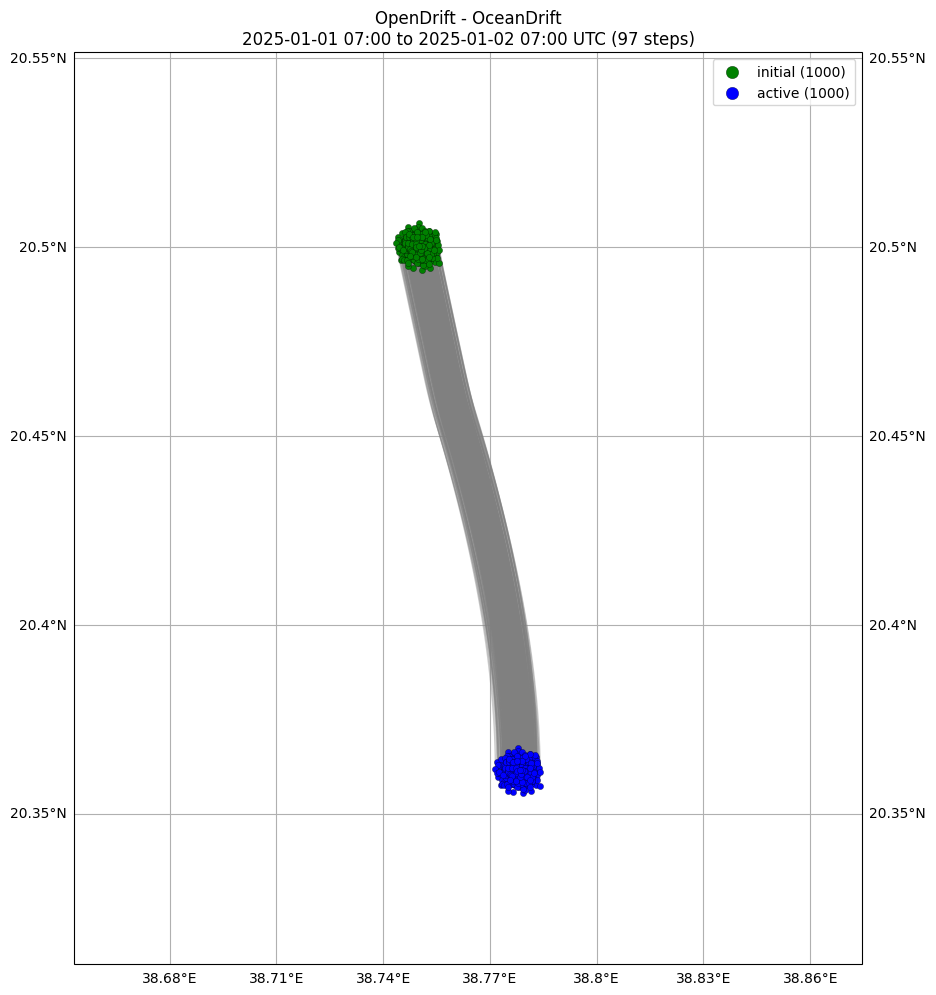

05:43:42 INFO    opendrift:3128: Preparing animation for notebook....


05:44:13 INFO    opendrift:3101: Time to make animation: 0:00:32.089303


In [7]:
o.plot()
o.animation()

05:45:57 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)
05:45:57 INFO    opendrift.readers:63: Opening file with xr.open_dataset
05:45:57 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'valid_time', 'x': 'longitude', 'y': 'latitude'}
05:45:57 INFO    opendrift.readers:63: Opening file with xr.open_dataset
05:45:57 INFO    opendrift.readers.reader_netCDF_CF_generic:299: Grid coordinates are detected, but proj4 string not given: assuming latlong
05:45:57 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'time', 'z': 'depth', 'y': 'latitude', 'x': 'longitude'}
05:45:57 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
05:45:57 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
05:45:57 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000

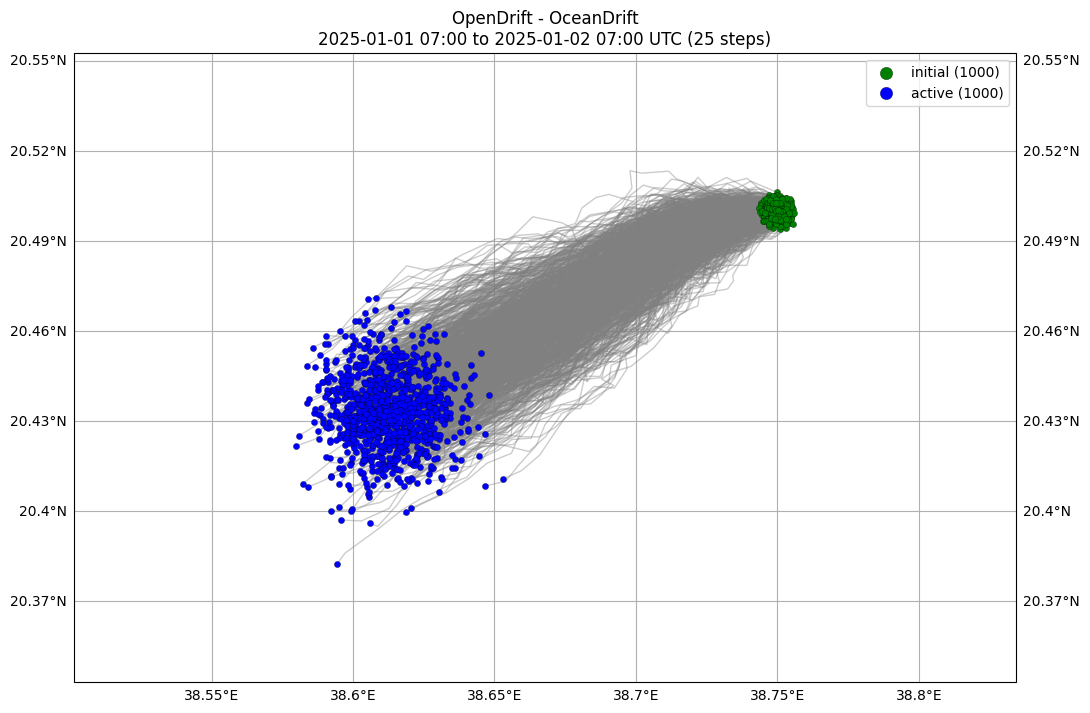

05:46:00 INFO    opendrift:3128: Preparing animation for notebook....


05:46:09 INFO    opendrift:3101: Time to make animation: 0:00:09.164169


In [11]:
from opendrift.models.oceandrift import OceanDrift
from opendrift.readers.reader_netCDF_CF_generic import Reader
from datetime import datetime, timedelta

o = OceanDrift(loglevel=20)

# add wind
wind_reader = Reader(
    "./wind_data2.nc",
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)
o.add_reader(wind_reader)

# add currents
current_reader = Reader(
    "./ocean_current.nc",
    standard_name_mapping={
        'uo': 'x_sea_water_velocity',
        'vo': 'y_sea_water_velocity'
    }
)
o.add_reader(current_reader)

# physics
o.set_config('drift:vertical_mixing', True)
o.set_config('drift:horizontal_diffusivity', 10)

# seed
o.seed_elements(
    lon=38.75,
    lat=20.50,
    radius=219.24,
    number=1000,
    time=datetime(2025,1,1,7)
)

# run
o.run(duration=timedelta(hours=24))

# plot
o.plot()
o.animation()

In [9]:
o = OceanDrift(loglevel=20)

05:45:45 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)


In [10]:
o.plot()
o.animation()

AttributeError: 'OceanDrift' object has no attribute 'elements_scheduled'

# Mask wala Attempt

In [53]:
import rasterio
import numpy as np
from skimage.filters import threshold_otsu
from datetime import datetime, timedelta
from opendrift.models.oceandrift import OceanDrift

In [54]:
with rasterio.open("../Images/Oil/Images/00000.tif") as src:
    band1 = src.read(1).astype(float)
    band2 = src.read(2).astype(float)
    transform = src.transform
    crs = src.crs

# Normalize bands
band1_norm = (band1 - np.nanmin(band1)) / (np.nanmax(band1) - np.nanmin(band1))
band2_norm = (band2 - np.nanmin(band2)) / (np.nanmax(band2) - np.nanmin(band2))

# Combine 30:70
combined = 0.3 * band1_norm + 0.7 * band2_norm

In [55]:
valid_data = combined[~np.isnan(combined)]
threshold = threshold_otsu(valid_data)

oil_mask = combined < threshold

print("Otsu Threshold:", threshold)

# Remove small noisy blobs
oil_mask = remove_small_objects(oil_mask, min_size=200)

# Keep only largest connected component
labeled = label(oil_mask)
regions = np.bincount(labeled.flat)

# Ignore background label 0
regions[0] = 0
largest_region = regions.argmax()

oil_mask = labeled == largest_region

In [56]:
rows, cols = np.where(oil_mask)

spill_pixels = []

for r, c in zip(rows, cols):
    lon, lat = rasterio.transform.xy(transform, r, c)
    spill_pixels.append((lon, lat))

spill_pixels = np.array(spill_pixels)

print("Initial spill pixels:", len(spill_pixels))

Initial spill pixels: 1948353


In [57]:
rounded_lon = np.round(spill_pixels[:, 0], 3)
rounded_lat = np.round(spill_pixels[:, 1], 3)

spill_pixels = np.unique(
    np.column_stack((rounded_lon, rounded_lat)),
    axis=0
)

print("After spatial thinning:", len(spill_pixels))

After spatial thinning: 17229


In [63]:
o = OceanDrift(loglevel=20)

wind_reader = Reader(
    "./wind_fixed.nc",
    standard_name_mapping={
        'u10': 'x_wind',
        'v10': 'y_wind'
    }
)

current_reader = Reader(
    "./ocean_current.nc",
    standard_name_mapping={
        'uo': 'x_sea_water_velocity',
        'vo': 'y_sea_water_velocity'
    }
)

# o.add_reader(Reader("https://tds.hycom.org/thredds/dodsC/GLBy0.08/latest"))
# o.add_reader(Reader("https://nomads.ncep.noaa.gov:9090/dods/gfs_0p25/gfs_latest"))


o.add_reader(wind_reader)
o.add_reader(current_reader)

# Set physics BEFORE seeding
o.set_config('drift:vertical_mixing', False)
o.set_config('drift:horizontal_diffusivity', 10)

# Seed spill
o.seed_elements(
    lon=spill_pixels[:, 0],
    lat=spill_pixels[:, 1],
    time=datetime(2025, 1, 1, 7)
)

# Run simulation
o.run(
    duration=timedelta(hours=360),
    time_step=900
)

# Animate
o.animation(
    markersize=5,
    cmap='Reds',
    fast=True,
    filename="spill_drift_global_360.mp4"
)

09:57:56 INFO    opendrift:576: OpenDriftSimulation initialised (version 1.14.8)
09:57:56 INFO    opendrift.readers:63: Opening file with xr.open_dataset
09:57:56 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'time', 'x': 'longitude', 'y': 'latitude'}
09:57:56 INFO    opendrift.readers:63: Opening file with xr.open_dataset
09:57:56 INFO    opendrift.readers.reader_netCDF_CF_generic:299: Grid coordinates are detected, but proj4 string not given: assuming latlong
09:57:56 INFO    opendrift.readers.reader_netCDF_CF_generic:332: Detected dimensions: {'time': 'time', 'z': 'depth', 'y': 'latitude', 'x': 'longitude'}
09:57:56 INFO    opendrift.models.basemodel.environment:203: Adding a global landmask from GSHHG
09:57:56 INFO    opendrift.models.basemodel.environment:227: Fallback values will be used for the following variables which have no readers: 
09:57:56 INFO    opendrift.models.basemodel.environment:230: 	upward_sea_water_velocity: 0.000000
09:57

In [43]:
import xarray as xr

ds_wind = xr.open_dataset("./wind_data2.nc")
print(ds_wind)

ds_current = xr.open_dataset("./ocean_current.nc")
print(ds_current)

<xarray.Dataset> Size: 14kB
Dimensions:     (valid_time: 20, latitude: 9, longitude: 9)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 160B 2025-01-01T07:00:00 ... 2025...
    expver      (valid_time) <U4 320B ...
  * latitude    (latitude) float64 72B 21.5 21.25 21.0 20.75 ... 20.0 19.75 19.5
  * longitude   (longitude) float64 72B 37.5 37.75 38.0 ... 39.0 39.25 39.5
    number      int64 8B ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 6kB ...
    v10         (valid_time, latitude, longitude) float32 6kB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-11T16:40 GRIB to CDM+CF via cfgrib-0.9.1...
<xarray.Dataset> Size: 961kB
Dimensions:    (time: 80, depth: 1, latitude: 25, longitude

In [44]:
import xarray as xr

# Open wind dataset
ds_wind = xr.open_dataset("./wind_data2.nc")

# Rename valid_time → time
ds_wind = ds_wind.rename({'valid_time': 'time'})

# Save temporary corrected file
ds_wind.to_netcdf("wind_fixed.nc")

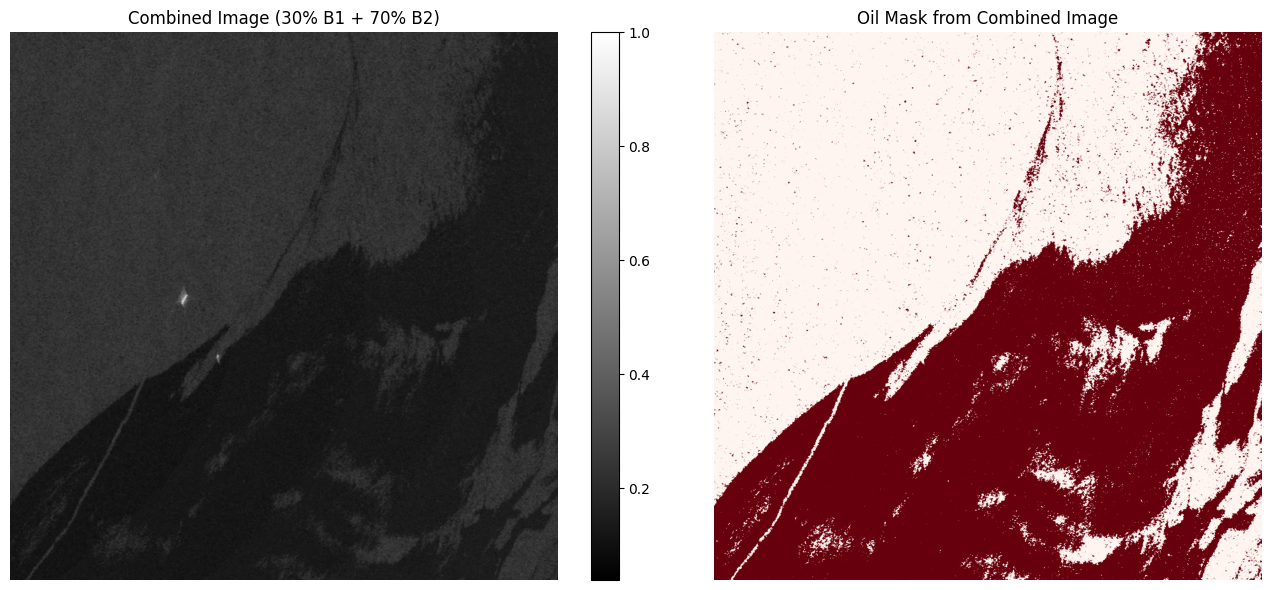

In [34]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

# Read TIFF
with rasterio.open("../Images/Oil/Images/00000.tif") as src:
    band1 = src.read(1).astype(float)
    band2 = src.read(2).astype(float)

# Normalize both bands
band1_norm = (band1 - np.nanmin(band1)) / (np.nanmax(band1) - np.nanmin(band1))
band2_norm = (band2 - np.nanmin(band2)) / (np.nanmax(band2) - np.nanmin(band2))

# Combine 30:70
combined = 0.3 * band1_norm + 0.7 * band2_norm

# Compute Otsu threshold
valid_data = combined[~np.isnan(combined)]
threshold = threshold_otsu(valid_data)

# Create oil mask (oil = darker region)
oil_mask = combined < threshold

# -------------------------
# Plot side-by-side
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Combined image
im = axes[0].imshow(combined, cmap='gray')
axes[0].set_title("Combined Image (30% B1 + 70% B2)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046)

# Oil mask
axes[1].imshow(oil_mask, cmap='Reds')
axes[1].set_title("Oil Mask from Combined Image")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [60]:
print(ds_current.latitude.min(), ds_current.latitude.max())
print(ds_current.longitude.min(), ds_current.longitude.max())

<xarray.DataArray 'latitude' ()> Size: 4B
array(19.5, dtype=float32)
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north
    unit_long:      Degrees North
    axis:           Y <xarray.DataArray 'latitude' ()> Size: 4B
array(21.5, dtype=float32)
Attributes:
    standard_name:  latitude
    long_name:      Latitude
    units:          degrees_north
    unit_long:      Degrees North
    axis:           Y
<xarray.DataArray 'longitude' ()> Size: 4B
array(37.50001, dtype=float32)
Attributes:
    standard_name:  longitude
    long_name:      Longitude
    units:          degrees_east
    unit_long:      Degrees East
    axis:           X <xarray.DataArray 'longitude' ()> Size: 4B
array(39.41668, dtype=float32)
Attributes:
    standard_name:  longitude
    long_name:      Longitude
    units:          degrees_east
    unit_long:      Degrees East
    axis:           X
